In [292]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from os import listdir
from numpy import asarray
from numpy import save
import tensorflow as tf
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import classification_report
import datetime
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [293]:
df = pd.read_csv("wildfire_multi_region_dataset.csv")

df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  object 
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  object 
 7   daynight        15500 non-null  object 
 8   region          15500 non-null  object 
 9   country         15500 non-null  object 
 10  fire_type       15500 non-null  object 
 11  satellite       15500 non-null  object 
 12  instrument      15500 non-null  object 
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  object 
 16  confidence      15500 non-null  object 
 17  temp_max_c      15500 non-null 

In [295]:
df.isnull().sum()

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

In [296]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


In [297]:
df.shape

(15500, 21)

In [298]:
columnas_cat = df.select_dtypes(include=['object', 'category']).columns

for col in columnas_cat:
    print(f"Valores únicos en {col}:")
    print(df[col].unique())
    print("-" * 20)


Valores únicos en acq_date:
['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05'
 '2024-01-06' '2024-01-07' '2024-01-08' '2024-01-09' '2024-01-10'
 '2024-01-11' '2024-01-12' '2024-01-13' '2024-01-14' '2024-01-15'
 '2024-01-16' '2024-01-17' '2024-01-18' '2024-01-19' '2024-01-20'
 '2024-01-21' '2024-01-22' '2024-01-23' '2024-01-24' '2024-01-25'
 '2024-01-26' '2024-01-27' '2024-01-28' '2024-01-29' '2024-01-30'
 '2024-01-31' '2024-02-01' '2024-02-02' '2024-02-03' '2024-02-04'
 '2024-02-05' '2024-02-06' '2024-02-07' '2024-02-08' '2024-02-09'
 '2024-02-10' '2024-02-11' '2024-02-12' '2024-02-13' '2024-02-15'
 '2024-02-16' '2024-02-17' '2024-02-18' '2024-02-19' '2024-02-20'
 '2024-02-21' '2024-02-22' '2024-02-23' '2024-02-24' '2024-02-25'
 '2024-02-26' '2024-02-27' '2024-02-28' '2024-02-29' '2024-11-01'
 '2024-11-02' '2024-11-03' '2024-11-05' '2024-11-06' '2024-11-07'
 '2024-11-08' '2024-11-09' '2024-11-10' '2024-11-11' '2024-11-12'
 '2024-11-13' '2024-11-14' '2024-11-15' '2024-11

In [299]:
columnas_num = df.select_dtypes(include=['float64', 'int64']).columns

for col in columnas_num:
    print(f"Valores únicos en {col}:")
    print(df[col].unique())
    print("-" * 20)

Valores únicos en latitude:
[-16.7722 -41.196  -39.875  ...  -3.772    6.5688 -27.7634]
--------------------
Valores únicos en longitude:
[151.0241 130.1397 124.9104 ... -16.7081 -12.5954  44.2033]
--------------------
Valores únicos en acq_time:
[1133 1251 1326 ... 1408 1605 1016]
--------------------
Valores únicos en year:
[2024 2025]
--------------------
Valores únicos en month:
[ 1  2 11 12  6  7  8  9  3 10  4  5]
--------------------
Valores únicos en brightness_k:
[347.72 357.82 333.76 ... 377.47 297.73 356.97]
--------------------
Valores únicos en frp_mw:
[29.38 62.05  3.35 ... 64.84 78.96 68.71]
--------------------
Valores únicos en temp_max_c:
[42.1 43.8 35.4 39.6 46.7 45.4 42.3 46.8 35.  40.7 38.2 33.4 47.3 39.2
 40.9 41.9 38.8 47.1 46.  43.6 34.2 38.6 42.  41.4 39.1 33.5 35.8 36.
 36.1 39.5 33.9 40.2 41.1 38.4 40.6 37.9 37.  43.1 38.9 40.3 51.9 36.6
 42.5 41.  37.8 41.3 43.7 43.  49.6 35.7 46.2 41.7 38.  43.9 38.1 45.9
 31.6 32.2 35.6 43.2 37.6 45.1 30.5 36.8 36.9 38.3 3

In [300]:
columnas_a_borrar = [
    "acq_date",    # Ya tengo month y season 
    "satellite",   # Tecnología del sensor (no influye en el fuego)
    "instrument",  # Tecnología del sensor
    "country",     # Tengo la columna region que son 7
    "acq_time",    # La hora exacta puede ser muy ruidosa
    "year",        # Solo hay datos de 2024, 2025
    "latitude",    # Muy concreto, eliminarmos para evitar que memorice
    "longitude"    # Muy concreto, eliminarmos para evitar que memorice
]

df = df.drop(columns=columnas_a_borrar)

In [301]:
# Variables a escoger con las que voy a trabajar 
# Temperatura maxima, velocidad del viento maxima y precipitación.

variables = df[["temp_max_c", "wind_max_kmh", "precip_mm"]]

variables.head()



,temp_max_c,wind_max_kmh,precip_mm
0,42.1,1.7,0.47
1,43.8,2.2,0.27
2,35.4,4.4,0.35
3,39.6,34.7,0.30
4,46.7,16.7,6.49


  fire_intensity  count
0       Moderate   6861
1           High   4785
2            Low   2493
3        Extreme   1361


<Axes: xlabel='fire_intensity'>

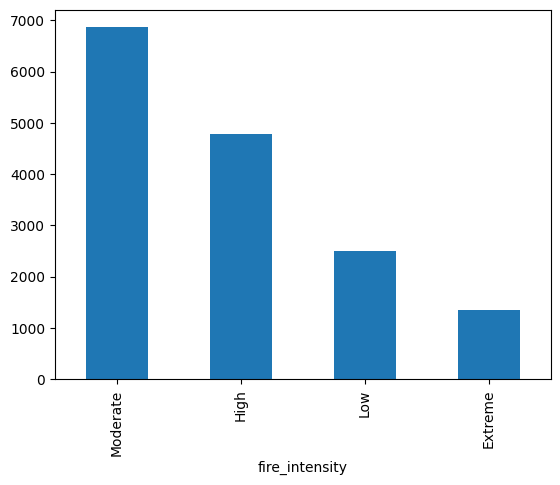

In [302]:
#Se observa un fuerte desbalance de clases. Esto implica que la Matriz de Confusión podría mostrar una alta precisión en la clase 'Low', pero debemos vigilar de cerca la clase 'Extreme',
#ya que el modelo tendrá menos ejemplos para aprender a identificarla
tabla_distribucion = df['fire_intensity'].value_counts().reset_index()
print(tabla_distribucion)
df['fire_intensity'].value_counts().plot(kind='bar')

In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           15500 non-null  int64  
 1   season          15500 non-null  object 
 2   daynight        15500 non-null  object 
 3   region          15500 non-null  object 
 4   fire_type       15500 non-null  object 
 5   brightness_k    15500 non-null  float64
 6   frp_mw          15500 non-null  float64
 7   fire_intensity  15500 non-null  object 
 8   confidence      15500 non-null  object 
 9   temp_max_c      15500 non-null  float64
 10  wind_max_kmh    15500 non-null  float64
 11  precip_mm       15500 non-null  float64
 12  humidity_pct    15500 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 1.5+ MB


In [304]:
cols_to_dummies = ['season', 'daynight', 'region', 'fire_type', 'confidence']
df = pd.get_dummies(df, columns=cols_to_dummies, drop_first=True, dtype=int)

In [305]:
# Mapeo de la variable objetivo
mapeo = {'Low': 0, 'Moderate': 1, 'High': 2, 'Extreme': 3}
df['fire_intensity_num'] = df['fire_intensity'].map(mapeo)

# Definimos las columnas "trampa" que queremos identificar
columnas_trampa = ['frp_mw', 'brightness_k']
# Definimos las 3 variables climáticas básicas
columnas_basicas = ['temp_max_c', 'humidity_pct', 'precip_mm']

In [306]:
df = df.drop(columns=["fire_intensity"])

In [307]:
df.shape

(15500, 29)

In [308]:
df.head()

,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,season_Spring,season_Summer,season_Winter,...,fire_type_Forest,fire_type_Grassland,fire_type_Peatland,fire_type_Prescribed,fire_type_Savanna,fire_type_Shrubland,fire_type_Wildfire,confidence_low,confidence_nominal,fire_intensity_num
0,1,347.72,29.38,42.1,1.7,0.47,18.4,0,1,0,...,1,0,0,0,0,0,0,0,0,1
1,1,357.82,62.05,43.8,2.2,0.27,11.7,0,1,0,...,0,0,0,0,0,0,0,0,1,2
2,1,333.76,3.35,35.4,4.4,0.35,5.0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,323.94,46.35,39.6,34.7,0.30,39.1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
4,1,359.59,434.80,46.7,16.7,6.49,53.1,0,1,0,...,1,0,0,0,0,0,0,0,0,3


In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      15500 non-null  int64  
 1   brightness_k               15500 non-null  float64
 2   frp_mw                     15500 non-null  float64
 3   temp_max_c                 15500 non-null  float64
 4   wind_max_kmh               15500 non-null  float64
 5   precip_mm                  15500 non-null  float64
 6   humidity_pct               15500 non-null  float64
 7   season_Spring              15500 non-null  int64  
 8   season_Summer              15500 non-null  int64  
 9   season_Winter              15500 non-null  int64  
 10  daynight_N                 15500 non-null  int64  
 11  region_Mediterranean       15500 non-null  int64  
 12  region_North_America       15500 non-null  int64  
 13  region_South_America       15500 non-null  int

In [310]:
df.corr()["fire_intensity_num"].abs().sort_values(ascending=False)[1:]

frp_mw                       0.617168
brightness_k                 0.389802
region_South_Asia            0.244512
humidity_pct                 0.161072
region_South_America         0.140744
region_North_America         0.129648
season_Summer                0.121395
temp_max_c                   0.105495
season_Spring                0.086788
region_Southeast_Asia        0.083774
fire_type_Grassland          0.073019
fire_type_Wildfire           0.069342
region_Mediterranean         0.067517
fire_type_Prescribed         0.063536
month                        0.060776
precip_mm                    0.060438
fire_type_Savanna            0.057563
fire_type_Peatland           0.052335
fire_type_Bushfire           0.047293
fire_type_Shrubland          0.042146
fire_type_Deforestation      0.031093
season_Winter                0.014874
region_Sub_Saharan_Africa    0.009889
confidence_low               0.009136
fire_type_Forest             0.009081
confidence_nominal           0.001243
daynight_N  

ESCENARIO 1: Clima Básico - Solamente seleccionando 3 variables: temp_max_c, humidity_pct, precip_mm

ESCENARIO 1: REPORTE
              precision    recall  f1-score   support

         Low       0.18      0.09      0.12       504
    Moderate       0.45      0.63      0.52      1357
        High       0.35      0.32      0.33       949
     Extreme       0.04      0.01      0.02       290

    accuracy                           0.39      3100
   macro avg       0.25      0.26      0.25      3100
weighted avg       0.33      0.39      0.35      3100



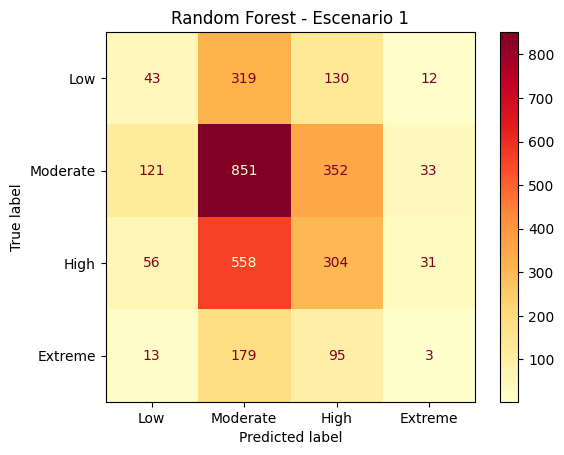

In [311]:
# 1. Selección de datos
X1 = df[columnas_basicas]
y1 = df['fire_intensity_num']

# 2. Split y Escalado
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# 3. Entrenamiento (Random Forest con balanceo)
rf1 = RandomForestClassifier(n_estimators=1000, max_depth=20, class_weight='balanced', random_state=42)
rf1.fit(X1_train_scaled, y1_train)

# 4. Resultados 
pred1 = rf1.predict(X1_test_scaled)
print("ESCENARIO 1: REPORTE")
print(classification_report(y1_test, pred1, target_names=['Low', 'Moderate', 'High', 'Extreme']))

disp = ConfusionMatrixDisplay.from_predictions(y1_test, pred1, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='YlOrRd')
plt.title("Random Forest - Escenario 1")
plt.show()

RESULTADOS SVM - ESCENARIO 1 con class_weight='balanced'
              precision    recall  f1-score   support

         Low       0.22      0.53      0.32       504
    Moderate       0.43      0.04      0.07      1357
        High       0.32      0.11      0.17       949
     Extreme       0.12      0.59      0.20       290

    accuracy                           0.19      3100
   macro avg       0.27      0.32      0.19      3100
weighted avg       0.33      0.19      0.15      3100



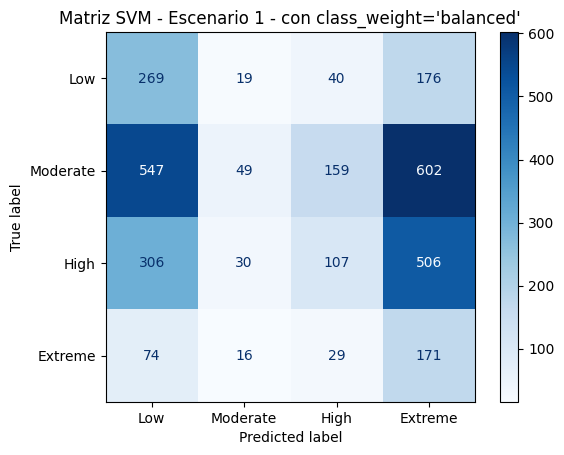

In [312]:
# --- SVM Escenario 1  con class_weight='balanced' ---

svm1 = SVC(kernel="linear", C=1.0, class_weight='balanced', random_state=42)
svm1.fit(X1_train_scaled, y1_train)

pred_svm1 = svm1.predict(X1_test_scaled)
print("RESULTADOS SVM - ESCENARIO 1 con class_weight='balanced'")
print(classification_report(y1_test, pred_svm1, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Visualizar Matriz SVM 1
disp = ConfusionMatrixDisplay.from_predictions(y1_test, pred_svm1, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='Blues')
plt.title("Matriz SVM - Escenario 1 - con class_weight='balanced'")
plt.show()

RESULTADOS SVM - ESCENARIO 1 sin class_weight='balanced'
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       504
    Moderate       0.44      1.00      0.61      1357
        High       0.00      0.00      0.00       949
     Extreme       0.00      0.00      0.00       290

    accuracy                           0.44      3100
   macro avg       0.11      0.25      0.15      3100
weighted avg       0.19      0.44      0.27      3100



c:\Users\Carmen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Carmen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Carmen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

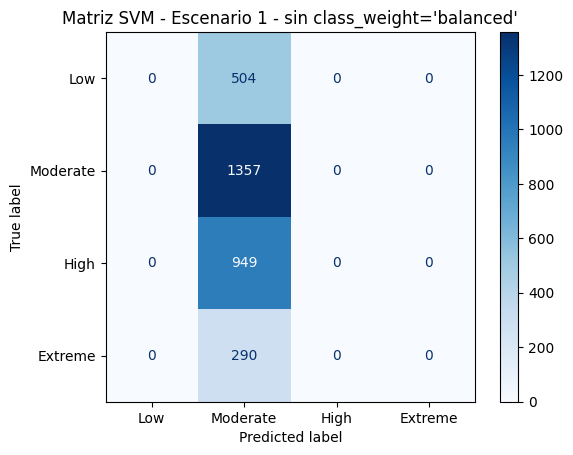

In [313]:
# --- SVM Escenario 1  sin class_weight='balanced' ---

svm1 = SVC(kernel="linear", C=1.0, random_state=42)
svm1.fit(X1_train_scaled, y1_train)

pred_svm1 = svm1.predict(X1_test_scaled)
print("RESULTADOS SVM - ESCENARIO 1 sin class_weight='balanced'")
print(classification_report(y1_test, pred_svm1, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Visualizar Matriz SVM 1
disp = ConfusionMatrixDisplay.from_predictions(y1_test, pred_svm1, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='Blues')
plt.title("Matriz SVM - Escenario 1 - sin class_weight='balanced'")
plt.show()

ESCENARIO 2: Modelo con Leakage (Trampa) - Todas las variables menos la objetivo.

ESCENARIO 2: REPORTE (99% Accuracy)
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       504
    Moderate       1.00      1.00      1.00      1357
        High       1.00      1.00      1.00       949
     Extreme       1.00      0.99      1.00       290

    accuracy                           1.00      3100
   macro avg       1.00      1.00      1.00      3100
weighted avg       1.00      1.00      1.00      3100



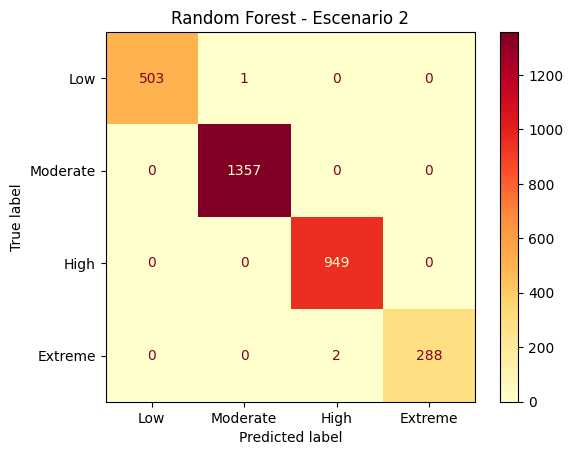

In [314]:
# 1. Selección de datos (Todas las numéricas excepto el objetivo)
X2 = df.drop(columns=['fire_intensity_num'])
y2 = df['fire_intensity_num']

# 2. Split y Escalado
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# 3. Entrenamiento
rf2 = RandomForestClassifier(n_estimators=1000, max_depth=20, class_weight='balanced', random_state=42)
rf2.fit(X2_train_scaled, y2_train)

# 4. Resultados
pred2 = rf2.predict(X2_test_scaled)
print("ESCENARIO 2: REPORTE (99% Accuracy)")
print(classification_report(y2_test, pred2, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Visualizar Random Forest
disp = ConfusionMatrixDisplay.from_predictions(y2_test, pred2, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='YlOrRd')
plt.title("Random Forest - Escenario 2")
plt.show()

RESULTADOS SVM - ESCENARIO 2 (Saturación/Trampa)
              precision    recall  f1-score   support

         Low       0.77      1.00      0.87       504
    Moderate       1.00      0.88      0.93      1357
        High       0.99      0.99      0.99       949
     Extreme       0.98      1.00      0.99       290

    accuracy                           0.94      3100
   macro avg       0.93      0.97      0.94      3100
weighted avg       0.95      0.94      0.94      3100



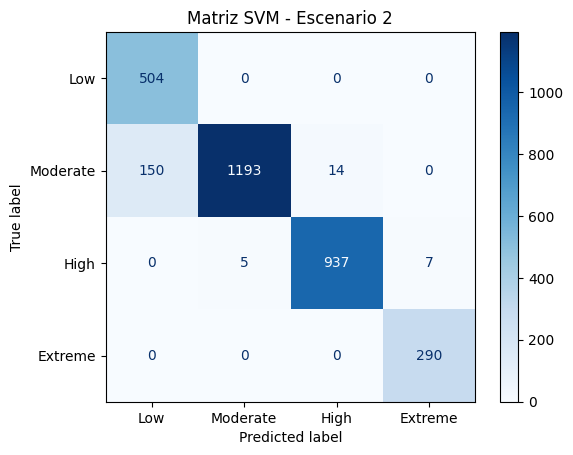

In [315]:
# --- SVM Escenario 2 ---
svm2 = SVC(kernel="linear", C=1.0, class_weight='balanced', random_state=42)
svm2.fit(X2_train_scaled, y2_train)

pred_svm2 = svm2.predict(X2_test_scaled)
print("RESULTADOS SVM - ESCENARIO 2 (Saturación/Trampa)")
print(classification_report(y2_test, pred_svm2, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Visualizar Matriz SVM 2
disp = ConfusionMatrixDisplay.from_predictions(y2_test, pred_svm2, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='Blues')
plt.title("Matriz SVM - Escenario 2")
plt.show()


ESCENARIO 3: Modelo Predictivo Real - Todas las columnas menos la objetivo y las trampa: frp_mw, brightness_k

ESCENARIO 3: REPORTE (Modelo Real)
              precision    recall  f1-score   support

         Low       0.23      0.09      0.13       504
    Moderate       0.45      0.67      0.54      1357
        High       0.37      0.33      0.35       949
     Extreme       0.17      0.02      0.04       290

    accuracy                           0.41      3100
   macro avg       0.31      0.28      0.26      3100
weighted avg       0.36      0.41      0.37      3100



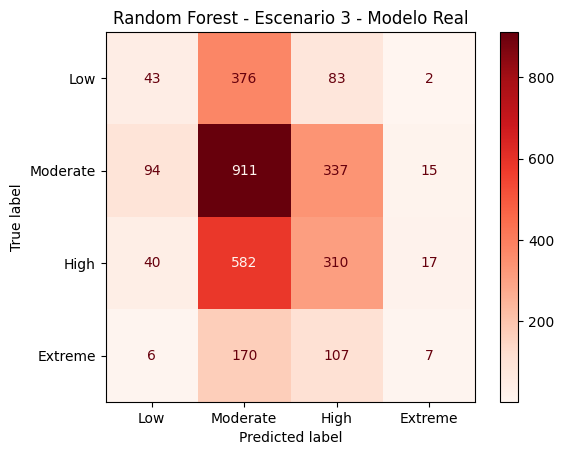

In [316]:
# 1. Selección de datos (Todas menos las "trampa")
X3 = X2.drop(columns=columnas_trampa)
y3 = df['fire_intensity_num']

# 2. Split y Escalado
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

# 3. Entrenamiento
rf3 = RandomForestClassifier(n_estimators=1000, max_depth=20, class_weight='balanced', random_state=42)
rf3.fit(X3_train_scaled, y3_train)

# 4. Resultados
pred3 = rf3.predict(X3_test_scaled)
print("ESCENARIO 3: REPORTE (Modelo Real)")
print(classification_report(y3_test, pred3, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Visualizar Random Forest
disp = ConfusionMatrixDisplay.from_predictions(y2_test, pred3, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='Reds')
plt.title("Random Forest - Escenario 3 - Modelo Real")
plt.show()

RESULTADOS SVM - ESCENARIO 3 (Modelo Real)
              precision    recall  f1-score   support

         Low       0.27      0.64      0.38       504
    Moderate       0.49      0.18      0.26      1357
        High       0.00      0.00      0.00       949
     Extreme       0.14      0.67      0.23       290

    accuracy                           0.25      3100
   macro avg       0.22      0.37      0.22      3100
weighted avg       0.27      0.25      0.20      3100



c:\Users\Carmen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Carmen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Carmen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

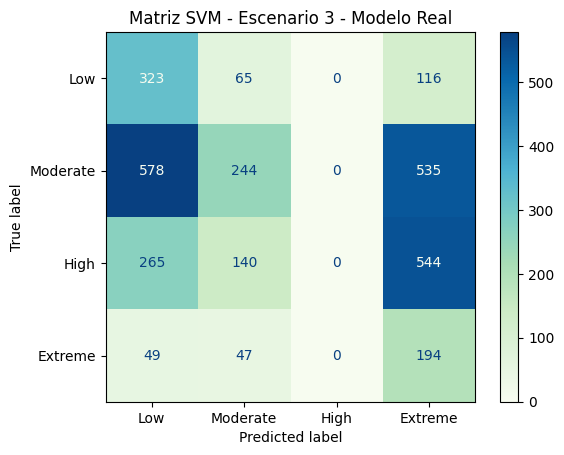

In [318]:
# --- SVM Escenario 3 ---
svm3 = SVC(kernel="linear", C=1.0, class_weight='balanced', random_state=42)
svm3.fit(X3_train_scaled, y3_train)

pred_svm3 = svm3.predict(X3_test_scaled)
print("RESULTADOS SVM - ESCENARIO 3 (Modelo Real)")
print(classification_report(y3_test, pred_svm3, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Visualizar Matriz SVM 3
disp = ConfusionMatrixDisplay.from_predictions(y3_test, pred_svm3, 
                                              display_labels=['Low', 'Moderate', 'High', 'Extreme'],
                                              cmap='GnBu')
plt.title("Matriz SVM - Escenario 3 - Modelo Real")
plt.show()